In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_mean_and_diff(
    data_original, data_perturbed, data_name,
    n_rows=5, n_cols=5,
    figsize=(15, 15),   # 整个 figure 的尺寸 (宽, 高)
    unified_cscale=True,  # 是否让所有子图共享同一个 color scale（min/max）
    cmap_pert='viridis', cmap_diff='seismic'
):
    """
    绘制 data_perturbed 的平均图像和 data_perturbed 与 data_original 的差异图。
    假设 data_original["y"] 和 data_perturbed["y"] 的形状都是 (N, H, W, C)。

    参数：
        data_original: 包含 key "y" 的 dict 或类似结构
        data_perturbed: 包含 key "y" 的 dict 或类似结构
        data_name: 字符串，用于图标题标注
        n_rows, n_cols: 子图的行列数（默认 5×5）
        figsize: matplotlib 的 figure 大小 (宽, 高)
        unified_cscale: 如果 True，则子图共享同一个 color scale；
                        如果 False，则每个子图有自己最优的 color scale。
        cmap_pert, cmap_diff: perturbed 平均图 和 差异图 的 colormap
    """
    y_orig = data_original["y"]#[:200]
    y_pert = data_perturbed["y"]#[:200]

    # 对第 0 维求平均
    mean_orig = y_orig.mean(dim=0)
    mean_pert = y_pert.mean(dim=0)
    diff = mean_pert - mean_orig

    H, W, C = mean_pert.shape  # 通道数 C

    # 转为 numpy 列表
    imgs_pert = [mean_pert[:, :, i].detach().cpu().numpy() for i in range(C)]
    imgs_diff = [diff[:, :, i].detach().cpu().numpy() for i in range(C)]

    def pad_to_n(img_list, n, H, W):
        while len(img_list) < n:
            img_list.append(np.zeros((H, W), dtype=img_list[0].dtype))
        return img_list

    total = n_rows * n_cols
    imgs_pert_padded = pad_to_n(imgs_pert.copy(), total, H, W)
    imgs_diff_padded = pad_to_n(imgs_diff.copy(), total, H, W)

    # 如果统一 color scale，计算全局的 vmin/vmax
    if unified_cscale:
        all_pert = np.concatenate([img.flatten() for img in imgs_pert])
        vmin_pert, vmax_pert = all_pert.min(), all_pert.max()
        all_diff = np.concatenate([img.flatten() for img in imgs_diff])
        vmin_diff, vmax_diff = all_diff.min(), all_diff.max()
    else:
        vmin_pert = vmax_pert = None
        vmin_diff = vmax_diff = None

    def plot_grid(imgs, n_rows, n_cols, cmap, title, global_vmin=None, global_vmax=None):
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
        for i in range(n_rows * n_cols):
            r = i // n_cols
            c = i % n_cols
            ax = axes[r, c]
            if i < len(imgs):
                img = imgs[i]
                if unified_cscale:
                    im = ax.imshow(img, cmap=cmap, vmin=global_vmin, vmax=global_vmax)
                else:
                    im = ax.imshow(img, cmap=cmap)
                ax.axis('off')
            else:
                ax.axis('off')
        fig.suptitle(title, fontsize=16)
        fig.tight_layout(rect=[0, 0, 1, 0.96])

        # 加 colorbar：我们给最右下那个子图（axes[-1, -1]）添加 colorbar，
        # 或者你可以改成画在整行/整列旁边
        # 这里用最后一个 im 和整个 axes 画一个 colorbar
        fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
        return fig, axes

    # 画 perturbed 平均图
    title1 = f"{data_name} — Mean Perturbed (n={y_pert.shape[0]})"
    fig1, axes1 = plot_grid(
        imgs_pert_padded, n_rows, n_cols, cmap_pert,
        title1, global_vmin=vmin_pert, global_vmax=vmax_pert
    )

    # 画 差异图
    title2 = f"{data_name} — Difference (Perturbed − Original)"
    fig2, axes2 = plot_grid(
        imgs_diff_padded, n_rows, n_cols, cmap_diff,
        title2, global_vmin=vmin_diff, global_vmax=vmax_diff
    )

    plt.show()
    return (fig1, axes1), (fig2, axes2)


In [26]:
import torch

# data_name = "isoCircles"
data_name = "ringsCos"
data_original = torch.load(f"../all_patterns/{data_name}/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_forcingPattern{data_name}.pt", weights_only=False)
data_perturbed = torch.load(f"{data_name}_attack_N1150_train.pt")
data_perturbed["y"].shape

torch.Size([1150, 256, 256, 21])

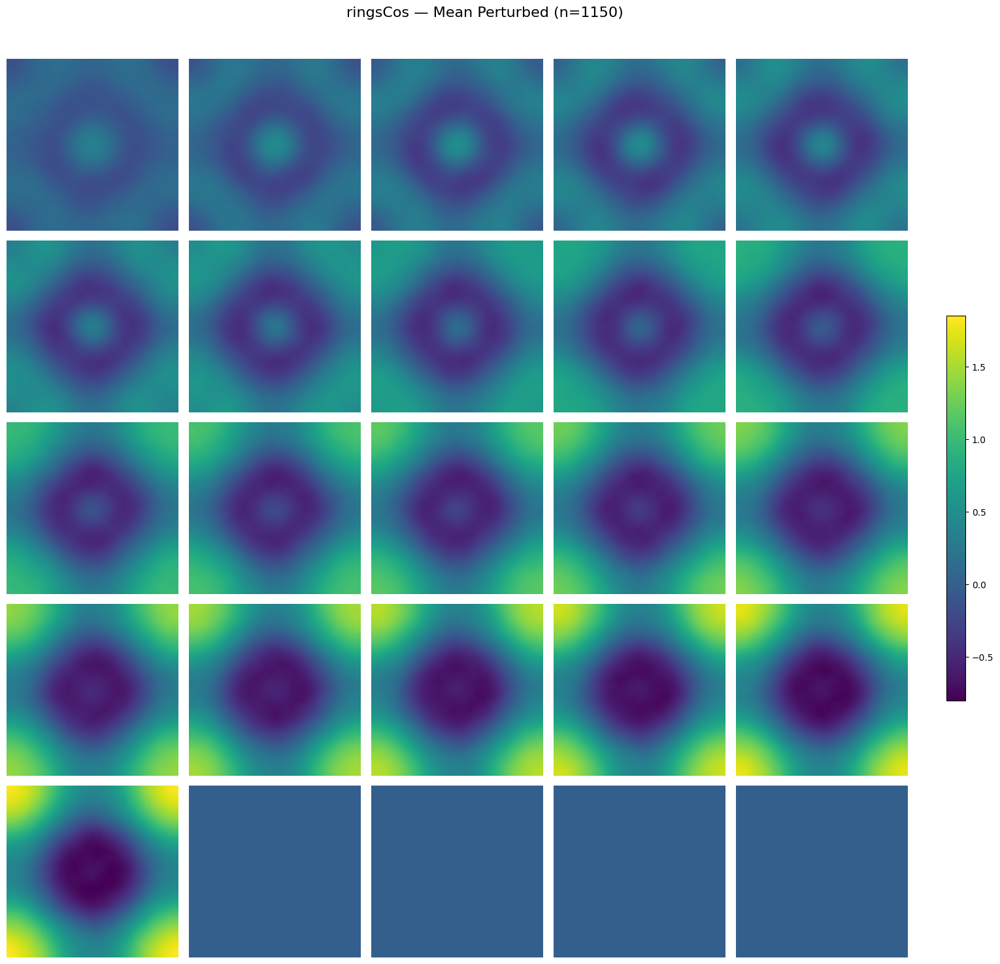

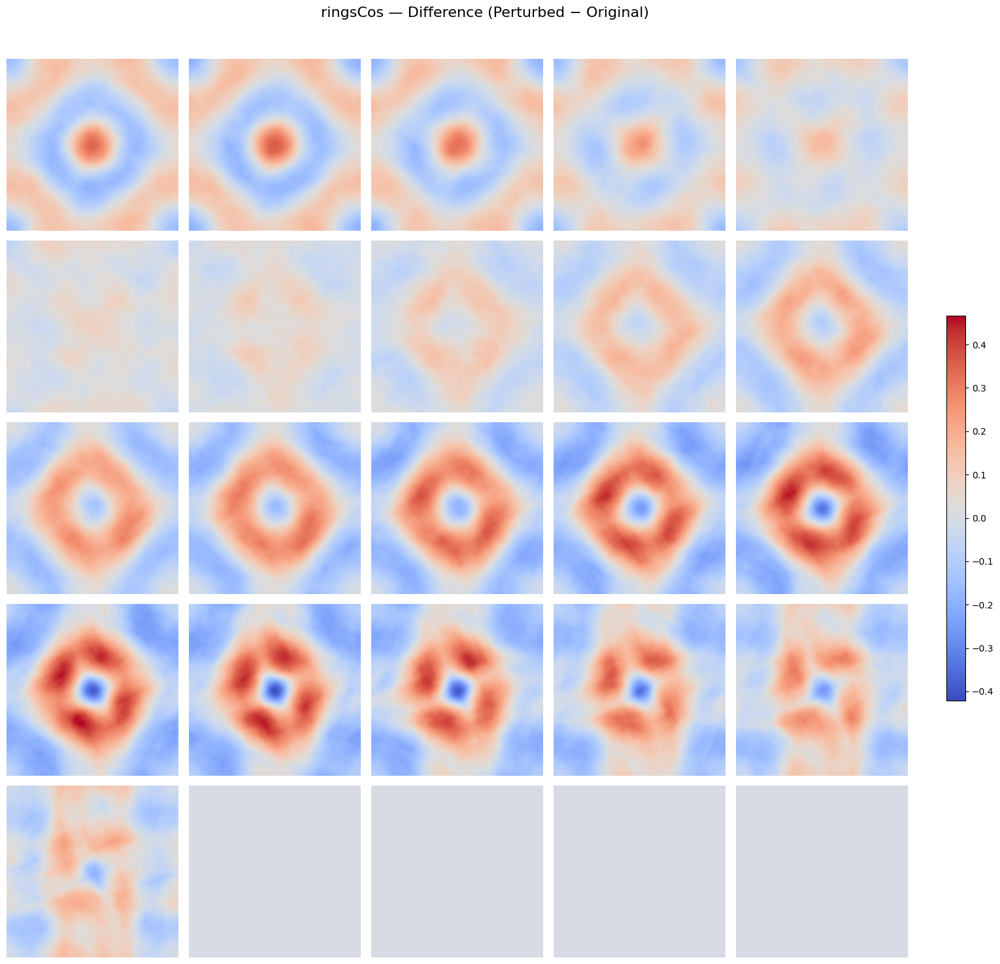

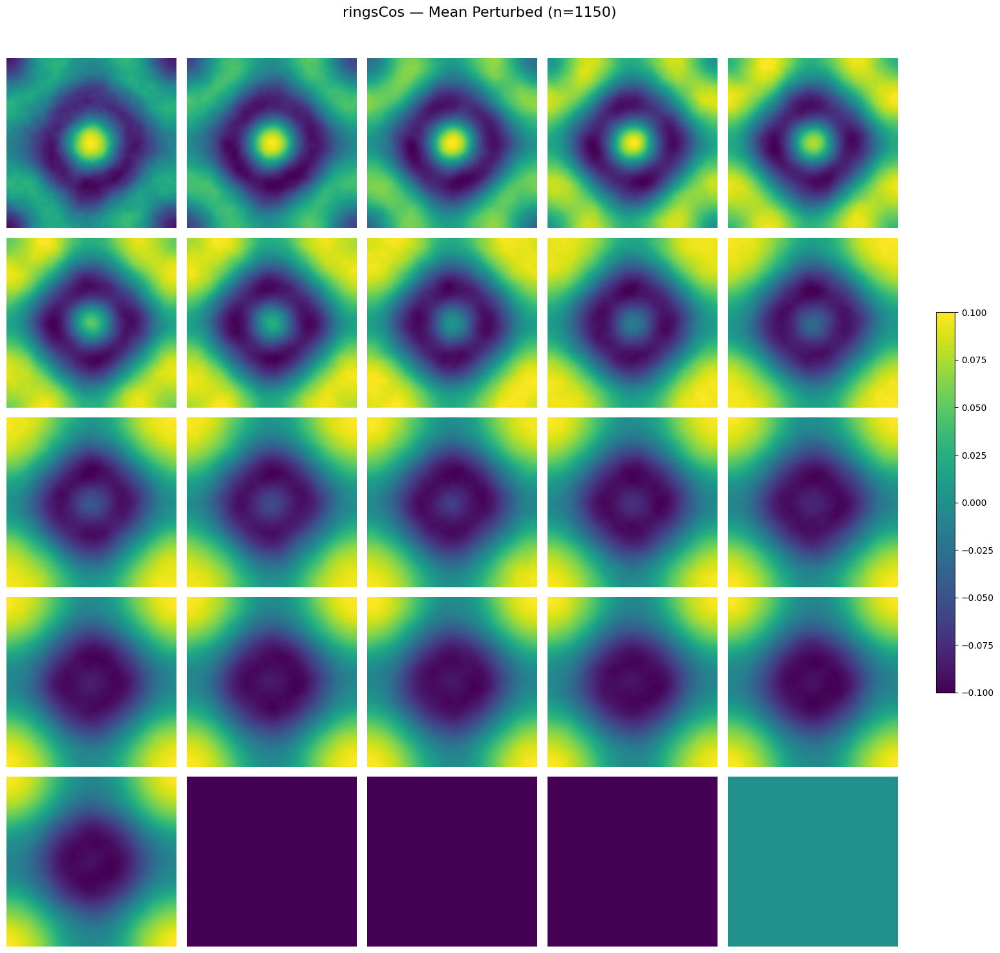

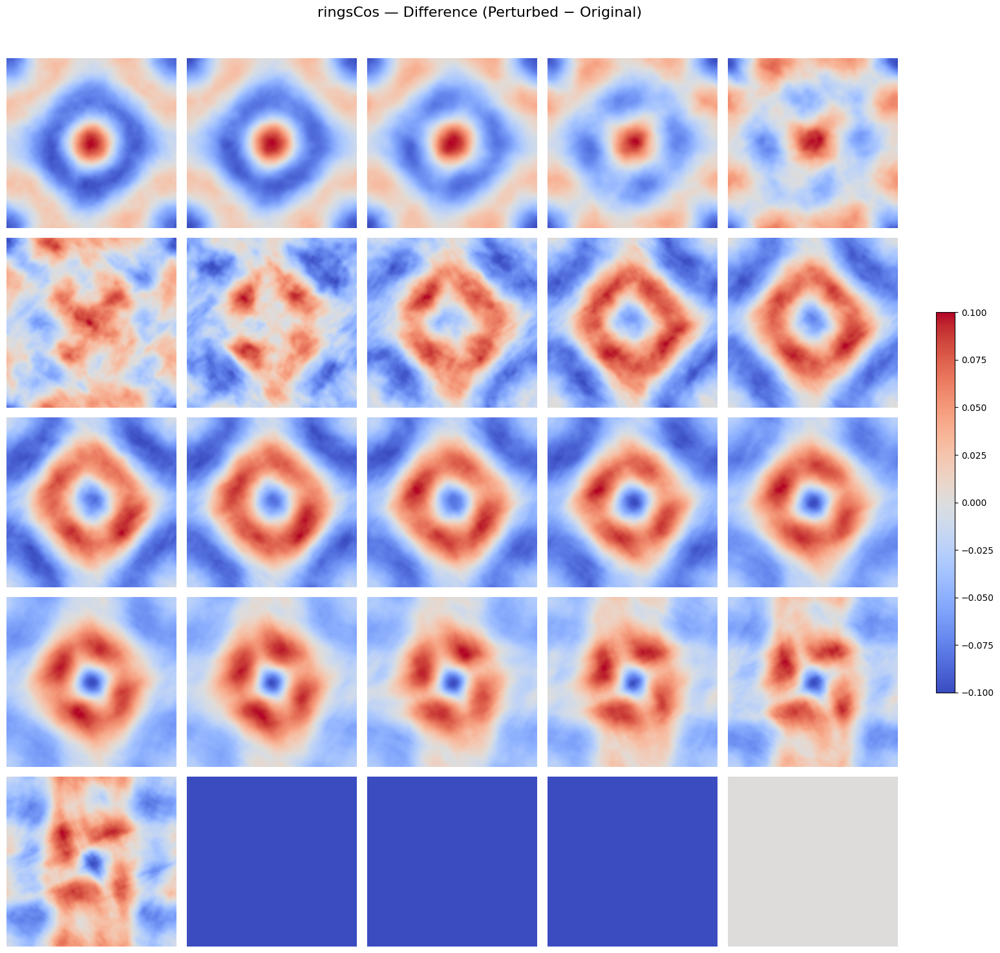

((<Figure size 1500x1500 with 26 Axes>,
  array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)),
 (<Figure size 1500x1500 with 26 Axes>,
  array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)))

In [27]:
plot_mean_and_diff(data_original, data_perturbed, data_name,
                   n_rows=5, n_cols=5,
                    figsize=(15, 15),   # 整个 figure 的尺寸 (宽, 高)
                    unified_cscale=True,  # 是否让所有子图共享同一个 color scale（min/max）
                    cmap_pert='viridis', cmap_diff='coolwarm'
                   )
plot_mean_and_diff(data_original, data_perturbed, data_name,
                   n_rows=5, n_cols=5,
                    figsize=(15, 15),   # 整个 figure 的尺寸 (宽, 高)
                    unified_cscale=False,  # 是否让所有子图共享同一个 color scale（min/max）
                    cmap_pert='viridis', cmap_diff='coolwarm'
                   )

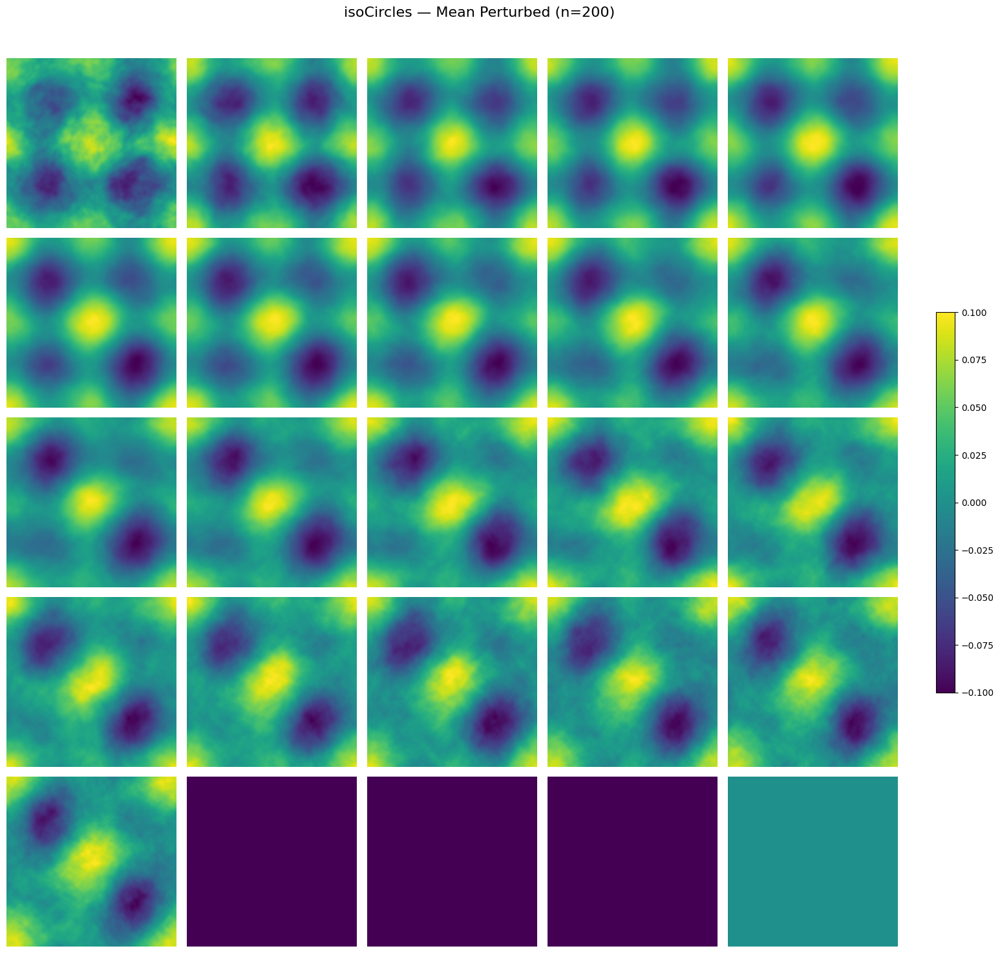

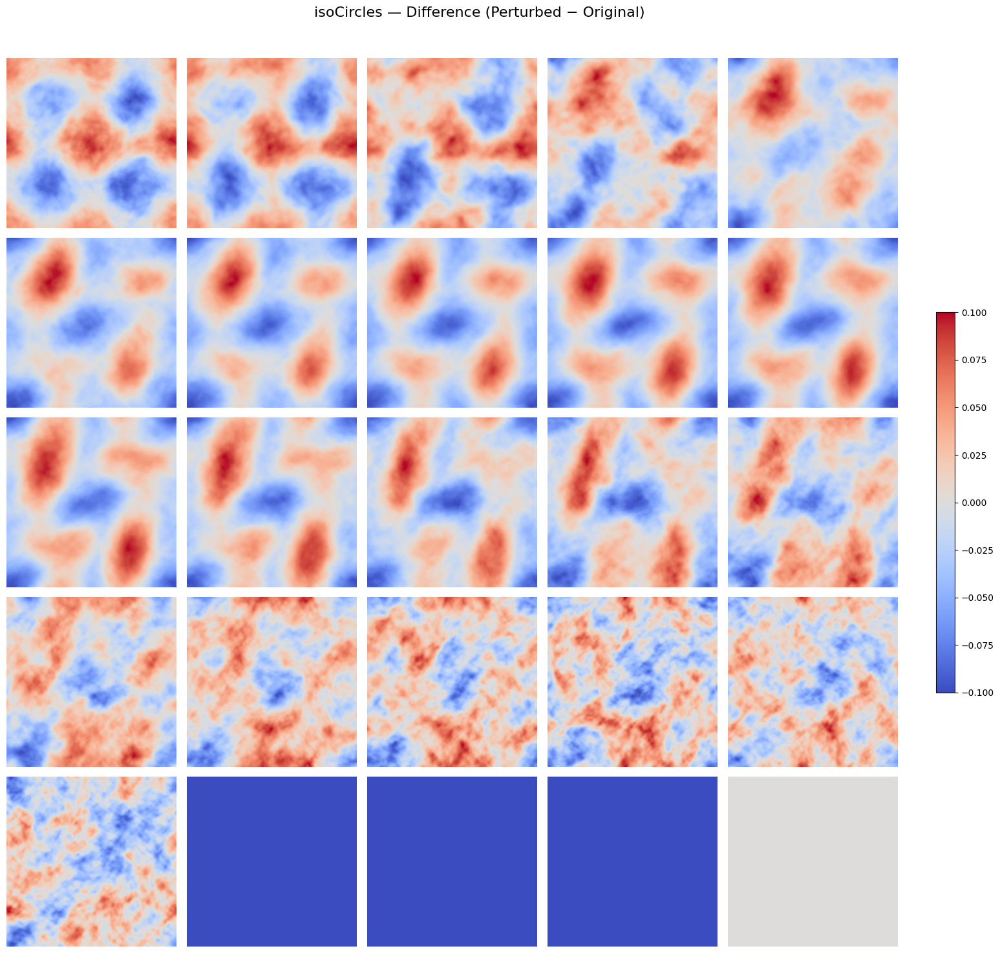

((<Figure size 1500x1500 with 26 Axes>,
  array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)),
 (<Figure size 1500x1500 with 26 Axes>,
  array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)))

In [19]:
plot_mean_and_diff(data_original, data_perturbed, data_name,
                   n_rows=5, n_cols=5,
                    figsize=(15, 15),   # 整个 figure 的尺寸 (宽, 高)
                    unified_cscale=False,  # 是否让所有子图共享同一个 color scale（min/max）
                    cmap_pert='viridis', cmap_diff='coolwarm'
                   )